In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import sys
sys.path.append('../src')
from features import load_and_clean, build_features, FEATURE_COLS, TARGET_COL

# Load and build features
df = load_and_clean('../data/raw/PJM_Load_hourly.csv')
df = build_features(df)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"Features: {len(FEATURE_COLS)}")


Dataset shape: (32736, 19)
Date range: 1998-04-08 01:00:00 → 2002-01-01 00:00:00
Features: 17


In [3]:
# Temporal train/test split — NEVER shuffle time series data
# Use last 3 months as test set
split_date = '2001-10-01'

train = df[df['Datetime'] < split_date].copy()
test  = df[df['Datetime'] >= split_date].copy()

print(f"Train: {train.shape} | {train['Datetime'].min().date()} → {train['Datetime'].max().date()}")
print(f"Test:  {test.shape}  | {test['Datetime'].min().date()} → {test['Datetime'].max().date()}")

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

# --- Naive baseline: predict lag_24 (same hour yesterday) ---
naive_preds = test['lag_24'].values

mae_naive  = mean_absolute_error(y_test, naive_preds)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_preds))
mape_naive = np.mean(np.abs((y_test.values - naive_preds) / y_test.values)) * 100

print(f"\n--- Naive Baseline (lag_24) ---")
print(f"MAE:  {mae_naive:,.0f} MW")
print(f"RMSE: {rmse_naive:,.0f} MW")
print(f"MAPE: {mape_naive:.2f}%")

Train: (30527, 19) | 1998-04-08 → 2001-09-30
Test:  (2209, 19)  | 2001-10-01 → 2002-01-01

--- Naive Baseline (lag_24) ---
MAE:  1,625 MW
RMSE: 2,372 MW
MAPE: 5.84%


In [4]:
# --- LightGBM Model ---
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'random_state': 42
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dval],
    callbacks=callbacks
)

# Evaluate
lgb_preds = model.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, lgb_preds)
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_preds))
mape_lgb = np.mean(np.abs((y_test.values - lgb_preds) / y_test.values)) * 100

print(f"\n--- LightGBM ---")
print(f"MAE:  {mae_lgb:,.0f} MW")
print(f"RMSE: {rmse_lgb:,.0f} MW")
print(f"MAPE: {mape_lgb:.2f}%")

print(f"\n--- Improvement over Baseline ---")
print(f"MAE  improvement: {(1 - mae_lgb/mae_naive)*100:.1f}%")
print(f"RMSE improvement: {(1 - rmse_lgb/rmse_naive)*100:.1f}%")
print(f"MAPE improvement: {(1 - mape_lgb/mape_naive)*100:.1f}%")

[100]	valid_0's l1: 798.154
[200]	valid_0's l1: 735.263
[300]	valid_0's l1: 716.736
[400]	valid_0's l1: 707.31
[500]	valid_0's l1: 701.527
[600]	valid_0's l1: 695.869
[700]	valid_0's l1: 693.975
[800]	valid_0's l1: 691.974

--- LightGBM ---
MAE:  692 MW
RMSE: 961 MW
MAPE: 2.51%

--- Improvement over Baseline ---
MAE  improvement: 57.4%
RMSE improvement: 59.5%
MAPE improvement: 57.0%


In [6]:
mkdir -p ~/energy-forecast/notebooks/plots

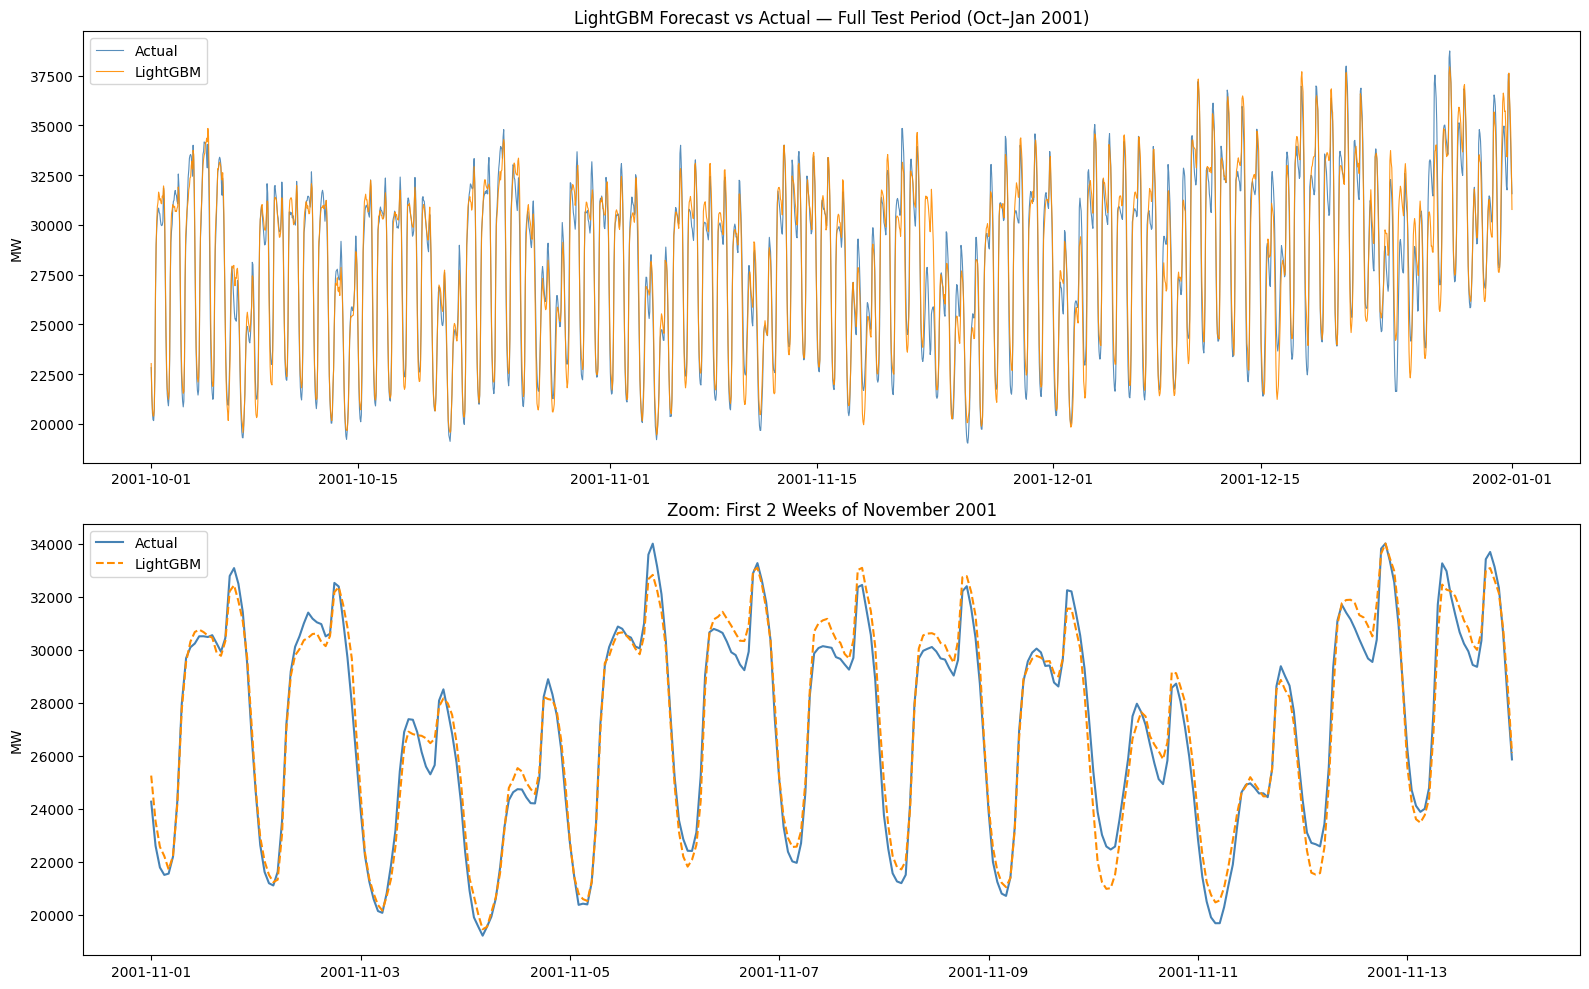

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Plot 1: Full test period ---
axes[0].plot(test['Datetime'].values, y_test.values, 
             label='Actual', color='steelblue', linewidth=0.8, alpha=0.9)
axes[0].plot(test['Datetime'].values, lgb_preds, 
             label='LightGBM', color='darkorange', linewidth=0.8, alpha=0.9)
axes[0].set_title('LightGBM Forecast vs Actual — Full Test Period (Oct–Jan 2001)')
axes[0].set_ylabel('MW')
axes[0].legend()

# --- Plot 2: Zoom into 2 weeks ---
zoom_start = '2001-11-01'
zoom_end   = '2001-11-14'
zoom_mask  = (test['Datetime'] >= zoom_start) & (test['Datetime'] <= zoom_end)
zoom_df    = test[zoom_mask]
zoom_preds = lgb_preds[zoom_mask.values]

axes[1].plot(zoom_df['Datetime'].values, zoom_df[TARGET_COL].values,
             label='Actual', color='steelblue', linewidth=1.5)
axes[1].plot(zoom_df['Datetime'].values, zoom_preds,
             label='LightGBM', color='darkorange', linewidth=1.5, linestyle='--')
axes[1].set_title('Zoom: First 2 Weeks of November 2001')
axes[1].set_ylabel('MW')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/plots/05_predictions.png', dpi=150)
plt.show()

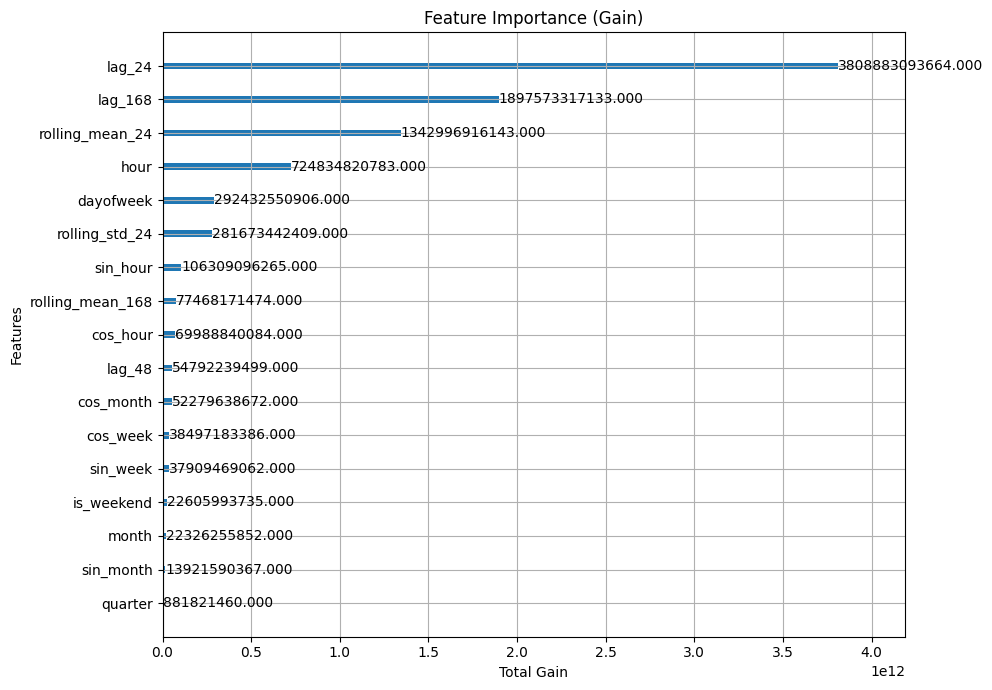

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

lgb.plot_importance(model, ax=ax, max_num_features=17, 
                    importance_type='gain',
                    title='Feature Importance (Gain)',
                    xlabel='Total Gain')
plt.tight_layout()
plt.savefig('../notebooks/plots/06_feature_importance.png', dpi=150)
plt.show()

In [9]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
model.save_model('../models/lgbm_energy.txt')

print("Model saved to models/lgbm_energy.txt")

# Final summary table
print("\n" + "="*45)
print("         FINAL RESULTS SUMMARY")
print("="*45)
print(f"{'Metric':<12} {'Naive':>10} {'LightGBM':>10} {'Δ':>8}")
print("-"*45)
print(f"{'MAE (MW)':<12} {mae_naive:>10,.0f} {mae_lgb:>10,.0f} {(1-mae_lgb/mae_naive)*100:>7.1f}%")
print(f"{'RMSE (MW)':<12} {rmse_naive:>10,.0f} {rmse_lgb:>10,.0f} {(1-rmse_lgb/rmse_naive)*100:>7.1f}%")
print(f"{'MAPE':<12} {mape_naive:>9.2f}% {mape_lgb:>9.2f}% {(1-mape_lgb/mape_naive)*100:>7.1f}%")
print("="*45)

Model saved to models/lgbm_energy.txt

         FINAL RESULTS SUMMARY
Metric            Naive   LightGBM        Δ
---------------------------------------------
MAE (MW)          1,625        692    57.4%
RMSE (MW)         2,372        961    59.5%
MAPE              5.84%      2.51%    57.0%
